# Sequence-aware Residual Neural Demapper cho BICM-ID trên kênh PA có memory

Notebook này thử hướng khác với demapper từng symbol:

```text
rx[k-W : k+W], La[k-W : k+W], Le_base[k-W : k+W] -> Delta LLR cho symbol k
```

Ý tưởng: PA thực tế có thể có **memory effect**, nghĩa là symbol thu hiện tại phụ thuộc không chỉ `x[k]` mà còn phụ thuộc các symbol lân cận. Khi nhìn một cửa sổ nhiều symbol, mạng có thể học phần nhiễu/méo liên ký tự này tốt hơn demapper từng symbol.

Hệ thống vẫn giữ:

- 16-QAM MSEW
- Extended Hamming (8,4)
- BICM-ID iterative receiver

So sánh:

- `mismatch`: classic demapper dùng `S_ORIG`, bỏ qua PA và memory.
- `memoryless_pa`: demapper biết PA memoryless nhưng vẫn bỏ qua memory.
- `sequence`: sequence residual NN, không nhận trực tiếp tham số PA/memory.

In [1]:
import os
import sys
import time
import json
import warnings

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams.update({"font.size": 12, "figure.figsize": (10, 6)})
%matplotlib inline

repo_root = os.path.abspath("..") if os.path.basename(os.getcwd()) == "python_code" else os.getcwd()
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from python_code.modulation import build_constellation, modulate_bits, symbol_bit_matrix
from python_code.demodulation import softdemod_qam, soft_demapper
from python_code.encoders import HammingEncoder
from python_code.decoders import DualDecoder
from python_code.interleavers import load_interleaver

np.random.seed(11)
tf.random.set_seed(11)

BPS = 4
CODE_RATE = 0.5
MAPRULE_MSEW = [11, 2, 1, 12, 4, 9, 10, 3, 5, 16, 15, 6, 14, 7, 8, 13]
S_ORIG = build_constellation(16, MAPRULE_MSEW, 10.0)
SYM_MATRIX = symbol_bit_matrix(16)

def snr_to_N0(dB):
    snr_lin = 10 ** (np.asarray(dB, dtype=np.float32) / 10.0) * BPS
    return (1.0 / snr_lin) / CODE_RATE

print("Project root:", repo_root)
print("Es original:", np.mean(np.abs(S_ORIG) ** 2))

Project root: c:\Users\Monkez-PC\Desktop\Luận Văn\BIBCM-ID-20260430T042613Z-3-001
Es original: 1.0


## 1. Kênh PA memory và các scenario

Training random hóa cả PA và memory taps. Khi inference, model **không nhận** `a_sat`, `p_rapp`, `alpha_pm`, hoặc hệ số memory.

`memoryless_pa` biết đúng PA memoryless của kịch bản test nhưng vẫn không biết/cân bằng memory, nên nó là baseline mạnh hơn mismatch nhưng chưa phải oracle hoàn hảo.

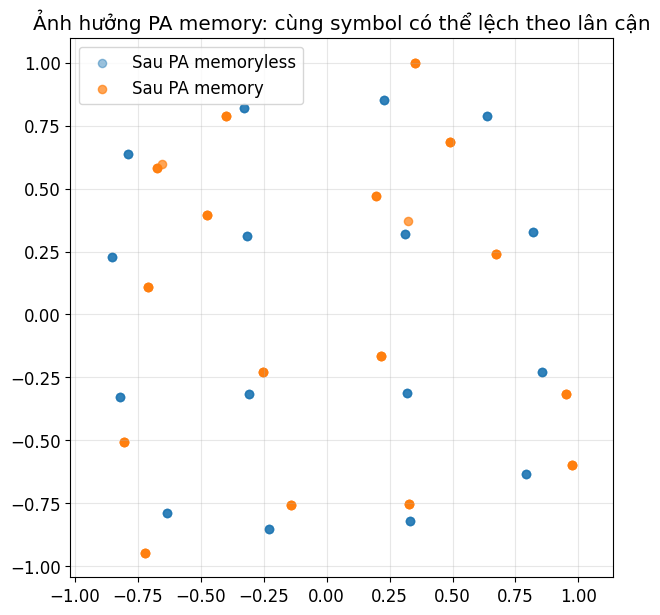

Train PA range: {'a_sat': (1.05, 1.55), 'p_rapp': (1.5, 3.5), 'alpha_pm': (0.0, 0.08), 'beta_pm': (0.0, 0.0)}
Train memory range: {'mem_pre': (-0.18, 0.18), 'mem_post': (-0.1, 0.1)}
Test scenarios: {'memoryless_mild_pa': {'pa': {'a_sat': 1.45, 'p_rapp': 2.5, 'alpha_pm': 0.02, 'beta_pm': 0.0}, 'memory': {'mem_pre': 0.0, 'mem_post': 0.0}}, 'seen_memory_strong_pa': {'pa': {'a_sat': 1.12, 'p_rapp': 2.0, 'alpha_pm': 0.06, 'beta_pm': 0.0}, 'memory': {'mem_pre': 0.16, 'mem_post': -0.06}}, 'edge_memory_unseen_pa': {'pa': {'a_sat': 0.98, 'p_rapp': 1.35, 'alpha_pm': 0.1, 'beta_pm': 0.0}, 'memory': {'mem_pre': 0.24, 'mem_post': -0.14}}}


In [2]:
def rapp_pa_complex(x, a_sat=1.2, p_rapp=2.0, alpha_pm=0.05, beta_pm=0.0):
    x = np.asarray(x, dtype=np.complex128)
    r = np.abs(x)
    theta = np.angle(x)
    ratio = r / a_sat
    g_r = r / ((1.0 + ratio ** (2.0 * p_rapp)) ** (1.0 / (2.0 * p_rapp)))
    phi_pa = alpha_pm * r**2 / (1.0 + beta_pm * r**2)
    return g_r * np.exp(1j * (theta + phi_pa))

def apply_pa_memory(x_pa, mem_pre=0.0, mem_post=0.0):
    # Short nonlinear memory: y[k] depends on PA(x[k-1]), PA(x[k]), PA(x[k+1]).
    y = x_pa.astype(np.complex128).copy()
    if mem_pre != 0.0:
        y[1:] += mem_pre * x_pa[:-1]
    if mem_post != 0.0:
        y[:-1] += mem_post * x_pa[1:]
    p_in = np.mean(np.abs(x_pa) ** 2) + 1e-12
    p_out = np.mean(np.abs(y) ** 2) + 1e-12
    return y * np.sqrt(p_in / p_out)

def awgn_complex(x, N0):
    noise = np.random.randn(*x.shape) + 1j * np.random.randn(*x.shape)
    return x + np.sqrt(N0 / 2.0) * noise

TRAIN_PA_RANGE = {
    "a_sat": (1.05, 1.55),
    "p_rapp": (1.5, 3.5),
    "alpha_pm": (0.00, 0.08),
    "beta_pm": (0.00, 0.00),
}
TRAIN_MEMORY_RANGE = {
    "mem_pre": (-0.18, 0.18),
    "mem_post": (-0.10, 0.10),
}

TEST_SCENARIOS = {
    "memoryless_mild_pa": {
        "pa": {"a_sat": 1.45, "p_rapp": 2.5, "alpha_pm": 0.02, "beta_pm": 0.0},
        "memory": {"mem_pre": 0.0, "mem_post": 0.0},
    },
    "seen_memory_strong_pa": {
        "pa": {"a_sat": 1.12, "p_rapp": 2.0, "alpha_pm": 0.06, "beta_pm": 0.0},
        "memory": {"mem_pre": 0.16, "mem_post": -0.06},
    },
    "edge_memory_unseen_pa": {
        "pa": {"a_sat": 0.98, "p_rapp": 1.35, "alpha_pm": 0.10, "beta_pm": 0.0},
        "memory": {"mem_pre": 0.24, "mem_post": -0.14},
    },
}

def sample_pa_cfg():
    return {
        "a_sat": float(np.random.uniform(*TRAIN_PA_RANGE["a_sat"])),
        "p_rapp": float(np.random.uniform(*TRAIN_PA_RANGE["p_rapp"])),
        "alpha_pm": float(np.random.uniform(*TRAIN_PA_RANGE["alpha_pm"])),
        "beta_pm": float(np.random.uniform(*TRAIN_PA_RANGE["beta_pm"])),
    }

def sample_memory_cfg():
    return {
        "mem_pre": float(np.random.uniform(*TRAIN_MEMORY_RANGE["mem_pre"])),
        "mem_post": float(np.random.uniform(*TRAIN_MEMORY_RANGE["mem_post"])),
    }

def constellation_after_pa(pa_cfg):
    return rapp_pa_complex(S_ORIG, **pa_cfg)

def iq_from_complex(x):
    return np.stack([x.real, x.imag], axis=-1).astype(np.float32)

demo = TEST_SCENARIOS["seen_memory_strong_pa"]
S_demo_pa = constellation_after_pa(demo["pa"])
demo_seq = np.tile(S_demo_pa, 5)[:64]
demo_mem = apply_pa_memory(demo_seq, **demo["memory"])

plt.figure(figsize=(7, 7))
plt.scatter(demo_seq.real, demo_seq.imag, s=35, alpha=0.45, label="Sau PA memoryless")
plt.scatter(demo_mem.real, demo_mem.imag, s=35, alpha=0.70, label="Sau PA memory")
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.title("Ảnh hưởng PA memory: cùng symbol có thể lệch theo lân cận")
plt.legend()
plt.show()

print("Train PA range:", TRAIN_PA_RANGE)
print("Train memory range:", TRAIN_MEMORY_RANGE)
print("Test scenarios:", TEST_SCENARIOS)

## 2. Sinh dữ liệu teacher cho sequence demapper

Ta tạo nhiều block symbol ngắn. Với mỗi block:

1. Sinh 16-QAM random.
2. Qua PA memory + AWGN.
3. `Le_base`: demapper mismatch dùng `S_ORIG`.
4. `Le_pa_ref`: demapper biết PA memoryless nhưng bỏ qua memory.
5. NN học LLR bằng bit label, đồng thời regularize residual để không sửa quá tay.

In [3]:
WINDOW_RADIUS = 3
WINDOW_LEN = 2 * WINDOW_RADIUS + 1
SEQ_LEN_TRAIN = 64

def random_apriori_llr(bits, sigma_min=0.45, sigma_max=4.0, drop_prob=0.25):
    sigma = np.random.uniform(sigma_min, sigma_max, size=(bits.shape[0], 1)).astype(np.float32)
    bpsk = 2.0 * bits.astype(np.float32) - 1.0
    ap_rx = bpsk + np.random.randn(*bits.shape).astype(np.float32) * sigma
    La = 2.0 * ap_rx / (sigma**2 + 1e-8)
    drop = (np.random.rand(bits.shape[0], 1) > drop_prob).astype(np.float32)
    return (La * drop).astype(np.float32)

def demap_frame(rx, La_flat, N0, S_ref):
    metrics = softdemod_qam(rx, float(N0), S_ref)
    return soft_demapper(metrics, La_flat.astype(np.float64), SYM_MATRIX).astype(np.float32)

def make_symbol_features(rx, La_mat, Le_base_mat):
    rx_iq = iq_from_complex(rx)
    radius = np.sqrt(np.sum(rx_iq**2, axis=1, keepdims=True) + 1e-8)
    phase = np.arctan2(rx_iq[:, 1:2], rx_iq[:, 0:1])
    phase_feat = np.concatenate([np.sin(phase), np.cos(phase)], axis=1).astype(np.float32)
    n_norm = np.linspace(0.0, 1.0, len(rx), dtype=np.float32).reshape(-1, 1)
    return np.concatenate([
        rx_iq,
        radius.astype(np.float32),
        phase_feat,
        np.clip(La_mat, -12, 12).astype(np.float32),
        np.clip(Le_base_mat, -20, 20).astype(np.float32),
        n_norm,
    ], axis=1).astype(np.float32)

def make_windows(features, radius=WINDOW_RADIUS):
    pad = np.pad(features, ((radius, radius), (0, 0)), mode="edge")
    return np.stack([pad[i:i + 2 * radius + 1] for i in range(len(features))]).astype(np.float32)

def generate_sequence_teacher_batch(num_blocks=64, seq_len=SEQ_LEN_TRAIN, snr_min=0.0, snr_max=7.0):
    all_windows = []
    all_bits = []
    all_pa_ref = []
    all_base = []
    all_N0 = []
    all_it = []

    for _ in range(num_blocks):
        pa_cfg = sample_pa_cfg()
        memory_cfg = sample_memory_cfg()
        S_pa = constellation_after_pa(pa_cfg)

        bits = np.random.randint(0, 2, size=(seq_len, BPS)).astype(np.float32)
        idx = (bits[:, 0] * 8 + bits[:, 1] * 4 + bits[:, 2] * 2 + bits[:, 3]).astype(np.int64)
        tx = S_ORIG[idx]

        snr_db = float(np.random.uniform(snr_min, snr_max))
        N0 = float(snr_to_N0(snr_db))
        tx_pa = rapp_pa_complex(tx, **pa_cfg)
        rx = awgn_complex(apply_pa_memory(tx_pa, **memory_cfg), N0)

        La = random_apriori_llr(bits)
        Le_base = demap_frame(rx, La.reshape(-1), N0, S_ORIG).reshape(-1, BPS)
        Le_pa_ref = demap_frame(rx, La.reshape(-1), N0, S_pa).reshape(-1, BPS)

        features = make_symbol_features(rx, La, Le_base)
        windows = make_windows(features)
        iteration = np.random.randint(1, 11, size=(seq_len, 1)).astype(np.float32)

        all_windows.append(windows)
        all_base.append(Le_base)
        all_pa_ref.append(Le_pa_ref)
        all_bits.append(bits.astype(np.float32))
        all_N0.append(np.full((seq_len, 1), N0, dtype=np.float32))
        all_it.append(iteration)

    return {
        "windows": np.concatenate(all_windows, axis=0),
        "Le_base": np.concatenate(all_base, axis=0).astype(np.float32),
        "Le_pa_ref": np.concatenate(all_pa_ref, axis=0).astype(np.float32),
        "bits": np.concatenate(all_bits, axis=0).astype(np.float32),
        "N0": np.concatenate(all_N0, axis=0).astype(np.float32),
        "iteration": np.concatenate(all_it, axis=0).astype(np.float32),
    }

sample = generate_sequence_teacher_batch(num_blocks=2)
for k, v in sample.items():
    print(k, v.shape, v.dtype)
print("feature dim:", sample["windows"].shape[-1])
print("base LLR std:", sample["Le_base"].std())

windows (128, 7, 14) float32
Le_base (128, 4) float32
Le_pa_ref (128, 4) float32
bits (128, 4) float32
N0 (128, 1) float32
iteration (128, 1) float32
feature dim: 14
base LLR std: 4.080983


## 3. Sequence residual neural demapper

Backbone dùng Conv1D trên cửa sổ symbol. Sau đó calibration học scale/offset LLR theo `N0` và iteration.

In [4]:
class SequenceResidualDemapper(tf.keras.Model):
    def __init__(self, m_bits=4):
        super().__init__()
        self.conv = tf.keras.Sequential([
            layers.Conv1D(64, 3, padding="same", activation="relu"),
            layers.Conv1D(96, 3, padding="same", activation="relu"),
            layers.GlobalAveragePooling1D(),
            layers.Dense(96, activation="relu"),
            layers.Dense(64, activation="relu"),
        ])
        self.delta_head = layers.Dense(m_bits, activation="linear")
        self.cal_net = tf.keras.Sequential([
            layers.Dense(32, activation="relu"),
            layers.Dense(32, activation="relu"),
            layers.Dense(2 * m_bits, activation="linear"),
        ])

    def call(self, windows, Le_base, N0, iteration, training=False):
        h = self.conv(windows, training=training)
        log_N0 = tf.math.log(N0 + 1e-8) / 3.0
        it_norm = tf.cast(iteration, tf.float32) / 10.0
        h2 = tf.concat([h, log_N0, it_norm], axis=-1)
        delta = self.delta_head(h2)
        Le_uncal = Le_base + delta

        params = self.cal_net(tf.concat([log_N0, it_norm], axis=-1), training=training)
        raw_scale, bias = tf.split(params, 2, axis=-1)
        scale = 0.25 + tf.nn.softplus(raw_scale)
        return scale * Le_uncal + bias, delta

seq_model = SequenceResidualDemapper()
optimizer = tf.keras.optimizers.Adam(1e-3)

dummy = generate_sequence_teacher_batch(num_blocks=1, seq_len=8)
_ = seq_model(
    tf.constant(dummy["windows"]),
    tf.constant(dummy["Le_base"]),
    tf.constant(dummy["N0"]),
    tf.constant(dummy["iteration"]),
)
print("Trainable variables:", len(seq_model.trainable_variables))

Trainable variables: 16


## 4. Huấn luyện

`QUICK_TRAIN=True` để kiểm tra nhanh. Khi lấy kết quả chính thức, đổi thành `False`.

step    1/250 | loss=0.4996 bce=0.4880 ref=0.1149 d2=0.0450 | 0.2s
step   25/250 | loss=0.5136 bce=0.5052 ref=0.0833 d2=0.0220 | 1.9s
step   50/250 | loss=0.4949 bce=0.4866 ref=0.0821 d2=0.0400 | 3.8s
step   75/250 | loss=0.5048 bce=0.4936 ref=0.1111 d2=0.0572 | 5.6s
step  100/250 | loss=0.4968 bce=0.4803 ref=0.1643 d2=0.0565 | 7.4s
step  125/250 | loss=0.4732 bce=0.4609 ref=0.1221 d2=0.0539 | 9.3s
step  150/250 | loss=0.4816 bce=0.4725 ref=0.0894 d2=0.0638 | 11.2s
step  175/250 | loss=0.4798 bce=0.4678 ref=0.1179 d2=0.0616 | 13.0s
step  200/250 | loss=0.4794 bce=0.4677 ref=0.1163 d2=0.0610 | 14.8s
step  225/250 | loss=0.4698 bce=0.4596 ref=0.1002 d2=0.0628 | 16.6s
step  250/250 | loss=0.4936 bce=0.4837 ref=0.0970 d2=0.0768 | 18.4s
Saved: c:\Users\Monkez-PC\Desktop\Luận Văn\BIBCM-ID-20260430T042613Z-3-001\python_code\sequence_memory_residual_demapper.weights.h5


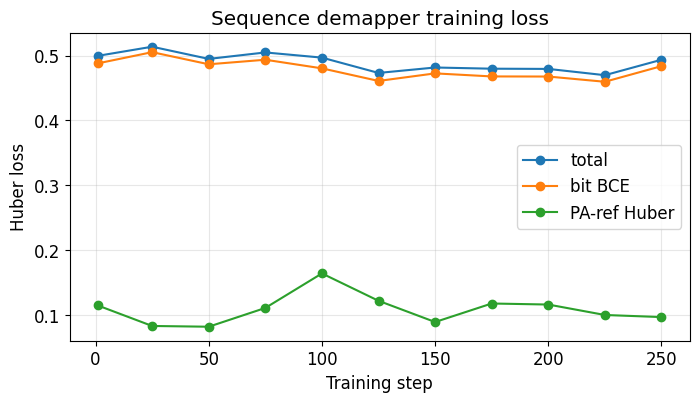

In [5]:
QUICK_TRAIN = True
TRAIN_STEPS = 250 if QUICK_TRAIN else 1000
BLOCKS_PER_BATCH = 24 if QUICK_TRAIN else 64
LOG_EVERY = 25
CKPT_PATH = os.path.join(repo_root, "python_code", "sequence_memory_residual_demapper.weights.h5")

train_log = []
start = time.time()
for step in range(1, TRAIN_STEPS + 1):
    batch = generate_sequence_teacher_batch(num_blocks=BLOCKS_PER_BATCH)
    with tf.GradientTape() as tape:
        Le_cal, delta = seq_model(
            tf.constant(batch["windows"]),
            tf.constant(batch["Le_base"]),
            tf.constant(batch["N0"]),
            tf.constant(batch["iteration"]),
            training=True,
        )
        bit_loss = tf.reduce_mean(tf.keras.losses.binary_crossentropy(tf.constant(batch["bits"]), Le_cal, from_logits=True))
        pa_ref_loss = tf.reduce_mean(tf.keras.losses.huber(tf.constant(batch["Le_pa_ref"]), Le_cal, delta=2.0))
        delta_penalty = tf.reduce_mean(tf.square(delta))
        loss = bit_loss + 0.10 * pa_ref_loss + 0.002 * delta_penalty

    grads = tape.gradient(loss, seq_model.trainable_variables)
    optimizer.apply_gradients(zip(grads, seq_model.trainable_variables))

    if step % LOG_EVERY == 0 or step == 1:
        rec = {
            "step": step,
            "loss": float(loss.numpy()),
            "bit_loss": float(bit_loss.numpy()),
            "pa_ref_loss": float(pa_ref_loss.numpy()),
            "delta_penalty": float(delta_penalty.numpy()),
            "elapsed_s": time.time() - start,
        }
        train_log.append(rec)
        print(
            f"step {step:4d}/{TRAIN_STEPS} | loss={rec['loss']:.4f} "
            f"bce={rec['bit_loss']:.4f} ref={rec['pa_ref_loss']:.4f} "
            f"d2={rec['delta_penalty']:.4f} | {rec['elapsed_s']:.1f}s"
        )

seq_model.save_weights(CKPT_PATH)
print("Saved:", CKPT_PATH)

plt.figure(figsize=(8, 4))
plt.plot([r["step"] for r in train_log], [r["loss"] for r in train_log], "-o", label="total")
plt.plot([r["step"] for r in train_log], [r["bit_loss"] for r in train_log], "-o", label="bit BCE")
plt.plot([r["step"] for r in train_log], [r["pa_ref_loss"] for r in train_log], "-o", label="PA-ref Huber")
plt.grid(True, alpha=0.3)
plt.xlabel("Training step")
plt.ylabel("Huber loss")
plt.title("Sequence demapper training loss")
plt.legend()
plt.show()

## 5. Kiểm tra LLR ở mức symbol

BCE mismatch    : 0.47538
BCE sequence    : 0.46238
BitAcc mismatch : 0.75620
BitAcc sequence : 0.76187


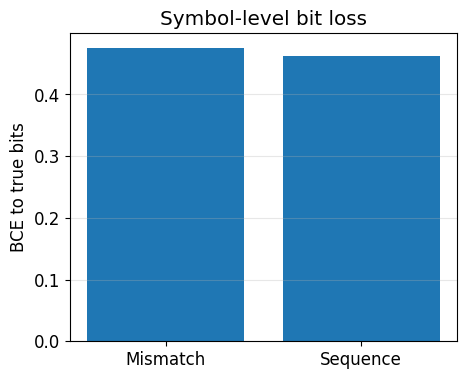

In [6]:
def evaluate_symbol_level(num_batches=8):
    bce_base, bce_seq, acc_base, acc_seq = [], [], [], []
    for _ in range(num_batches):
        b = generate_sequence_teacher_batch(num_blocks=16)
        Le_cal, _ = seq_model(
            tf.constant(b["windows"]),
            tf.constant(b["Le_base"]),
            tf.constant(b["N0"]),
            tf.constant(b["iteration"]),
            training=False,
        )
        prop = Le_cal.numpy()
        base = b["Le_base"]
        bits = b["bits"]
        bce_base.append(np.mean(tf.keras.losses.binary_crossentropy(bits, base, from_logits=True).numpy()))
        bce_seq.append(np.mean(tf.keras.losses.binary_crossentropy(bits, prop, from_logits=True).numpy()))
        acc_base.append(np.mean((base > 0).astype(np.float32) == bits))
        acc_seq.append(np.mean((prop > 0).astype(np.float32) == bits))
    return {
        "BCE mismatch": float(np.mean(bce_base)),
        "BCE sequence": float(np.mean(bce_seq)),
        "BitAcc mismatch": float(np.mean(acc_base)),
        "BitAcc sequence": float(np.mean(acc_seq)),
    }

symbol_metrics = evaluate_symbol_level()
for k, v in symbol_metrics.items():
    print(f"{k:16s}: {v:.5f}")

plt.figure(figsize=(5, 4))
plt.bar(["Mismatch", "Sequence"], [symbol_metrics["BCE mismatch"], symbol_metrics["BCE sequence"]])
plt.ylabel("BCE to true bits")
plt.title("Symbol-level bit loss")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## 6. Tích hợp vào vòng lặp BICM-ID

In [7]:
hamming_m = 3
encoder = HammingEncoder(hamming_m)
decoder = DualDecoder(encoder.H)
alpha = load_interleaver("BIBCM-ID_4096Algeb.mat")

num_channel_bits = len(alpha)
n_code = encoder.n_code
k_info = encoder.k_info
frame_len = num_channel_bits // n_code
info_len = frame_len * k_info
num_symbols = num_channel_bits // BPS
scaling_factor = 0.85

print("coded bits:", num_channel_bits, "symbols:", num_symbols)

def sequence_demap_numpy(rx, La_interleaved, N0, iteration):
    Le_base = demap_frame(rx, La_interleaved.reshape(-1), N0, S_ORIG).reshape(-1, BPS)
    features = make_symbol_features(rx, La_interleaved, Le_base)
    windows = make_windows(features)
    Le_cal_parts = []
    batch_size = 4096
    for start in range(0, len(windows), batch_size):
        end = start + batch_size
        n = end - start if end <= len(windows) else len(windows) - start
        Le_cal, _ = seq_model(
            tf.constant(windows[start:end], dtype=tf.float32),
            tf.constant(Le_base[start:end], dtype=tf.float32),
            tf.constant(np.full((n, 1), N0, dtype=np.float32)),
            tf.constant(np.full((n, 1), iteration + 1, dtype=np.float32)),
            training=False,
        )
        Le_cal_parts.append(Le_cal.numpy())
    return np.concatenate(Le_cal_parts, axis=0).reshape(-1)

def simulate_hamming_frame_memorypa(snr_dB, scenario, mode="mismatch", max_iter=10):
    pa_cfg = scenario["pa"]
    memory_cfg = scenario["memory"]
    S_pa = constellation_after_pa(pa_cfg)

    u = np.random.randint(0, 2, info_len)
    v = encoder.encode_frame(u)
    vv = v[alpha]

    tx = modulate_bits(vv, S_ORIG)
    N0 = float(snr_to_N0(snr_dB))
    tx_pa = rapp_pa_complex(tx, **pa_cfg)
    rx = awgn_complex(apply_pa_memory(tx_pa, **memory_cfg), N0)

    La_bits = np.zeros(num_channel_bits, dtype=np.float32)
    bit_errors = np.zeros(max_iter, dtype=np.float64)

    for iteration in range(max_iter):
        La_interleaved = La_bits[alpha].reshape(-1, BPS).astype(np.float32)
        if mode == "mismatch":
            Le_ext = demap_frame(rx, La_interleaved.reshape(-1), N0, S_ORIG)
        elif mode == "memoryless_pa":
            Le_ext = demap_frame(rx, La_interleaved.reshape(-1), N0, S_pa)
        elif mode == "sequence":
            Le_ext = sequence_demap_numpy(rx, La_interleaved, N0, iteration)
        else:
            raise ValueError(mode)

        Lc = np.zeros(num_channel_bits, dtype=np.float32)
        Lc[alpha] = Le_ext.astype(np.float32)
        Lc_post = decoder.decode_frame(Lc)
        La_bits = scaling_factor * (Lc_post - Lc)
        vhat = ((np.sign(Lc_post) + 1) / 2).astype(int)
        bit_errors[iteration] = np.sum(v != vhat)

    return bit_errors, num_channel_bits

print("Receiver functions are ready.")
print("Quick example: simulate_hamming_frame_memorypa(4.0, TEST_SCENARIOS['seen_memory_strong_pa'], mode='sequence', max_iter=2)")

coded bits: 4096 symbols: 1024
Receiver functions are ready.
Quick example: simulate_hamming_frame_memorypa(4.0, TEST_SCENARIOS['seen_memory_strong_pa'], mode='sequence', max_iter=2)


## 7. Mô phỏng BER

Draft mode chạy ít block để kiểm tra. Khi lấy số liệu báo cáo, đổi `QUICK_RUN=False`.

In [8]:
dB_range = [0, 1, 2, 3, 4, 4.5, 5, 5.5, 6]
MAX_ITER = 10
QUICK_RUN = True

BLOCKS_DRAFT = {0: 5, 1: 5, 2: 8, 3: 10, 4: 12, 4.5: 15, 5: 20, 5.5: 25, 6: 30}
BLOCKS_REPORT = {0: 80, 1: 80, 2: 120, 3: 160, 4: 250, 4.5: 400, 5: 700, 5.5: 900, 6: 1200}
BLOCKS_BY_SNR = BLOCKS_DRAFT if QUICK_RUN else BLOCKS_REPORT

def simulate_ber(modes=("mismatch", "memoryless_pa", "sequence")):
    results = {sc: {m: np.zeros((MAX_ITER, len(dB_range))) for m in modes} for sc in TEST_SCENARIOS}
    rows = []
    for sc_name, scenario in TEST_SCENARIOS.items():
        print("\nScenario:", sc_name, scenario)
        for mode in modes:
            print("  Mode:", mode)
            for z, snr in enumerate(dB_range):
                total_errs = np.zeros(MAX_ITER)
                total_bits = 0
                blocks = BLOCKS_BY_SNR[snr]
                start = time.time()
                for _ in range(blocks):
                    errs, nbits = simulate_hamming_frame_memorypa(snr, scenario, mode=mode, max_iter=MAX_ITER)
                    total_errs += errs
                    total_bits += nbits
                ber = total_errs / total_bits
                results[sc_name][mode][:, z] = ber
                row = {
                    "scenario": sc_name,
                    "mode": mode,
                    "snr_db": snr,
                    "blocks": blocks,
                    "bits": total_bits,
                    "ber_iter1": float(ber[0]),
                    "ber_iter5": float(ber[4]),
                    "ber_iter10": float(ber[9]),
                    "elapsed_s": time.time() - start,
                }
                rows.append(row)
                print(
                    f"    SNR={snr:>4} dB | Iter1={ber[0]:.3e} "
                    f"Iter5={ber[4]:.3e} Iter10={ber[9]:.3e} | blocks={blocks}"
                )
    return results, rows

BER_RESULTS, REPORT_ROWS = simulate_ber()


Scenario: memoryless_mild_pa {'pa': {'a_sat': 1.45, 'p_rapp': 2.5, 'alpha_pm': 0.02, 'beta_pm': 0.0}, 'memory': {'mem_pre': 0.0, 'mem_post': 0.0}}
  Mode: mismatch
    SNR=   0 dB | Iter1=3.462e-01 Iter5=3.381e-01 Iter10=3.381e-01 | blocks=5
    SNR=   1 dB | Iter1=3.143e-01 Iter5=3.017e-01 Iter10=3.014e-01 | blocks=5
    SNR=   2 dB | Iter1=2.798e-01 Iter5=2.529e-01 Iter10=2.529e-01 | blocks=8
    SNR=   3 dB | Iter1=2.472e-01 Iter5=2.012e-01 Iter10=2.001e-01 | blocks=10
    SNR=   4 dB | Iter1=2.065e-01 Iter5=1.272e-01 Iter10=1.059e-01 | blocks=12
    SNR= 4.5 dB | Iter1=1.763e-01 Iter5=6.069e-02 Iter10=8.757e-03 | blocks=15
    SNR=   5 dB | Iter1=1.627e-01 Iter5=2.267e-02 Iter10=0.000e+00 | blocks=20
    SNR= 5.5 dB | Iter1=1.334e-01 Iter5=2.188e-03 Iter10=0.000e+00 | blocks=25
    SNR=   6 dB | Iter1=1.127e-01 Iter5=3.255e-05 Iter10=0.000e+00 | blocks=30
  Mode: memoryless_pa
    SNR=   0 dB | Iter1=3.398e-01 Iter5=3.321e-01 Iter10=3.321e-01 | blocks=5
    SNR=   1 dB | Iter1=3.0

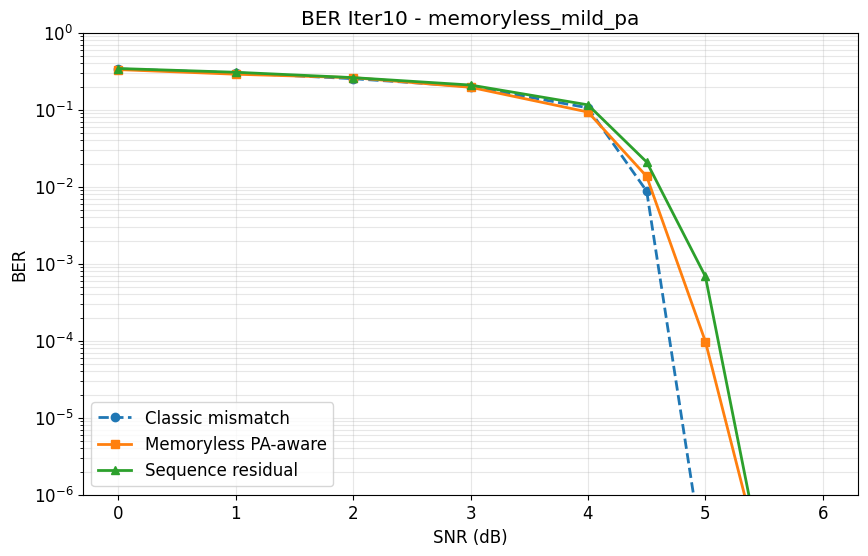

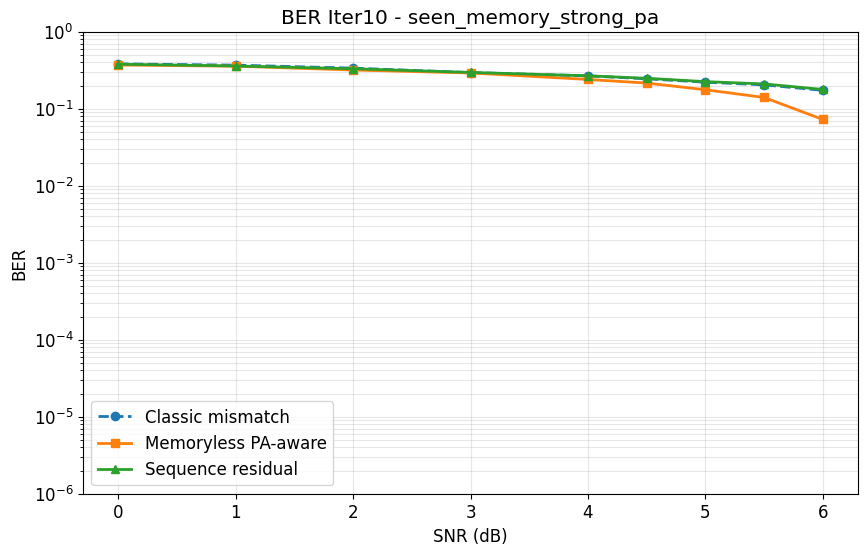

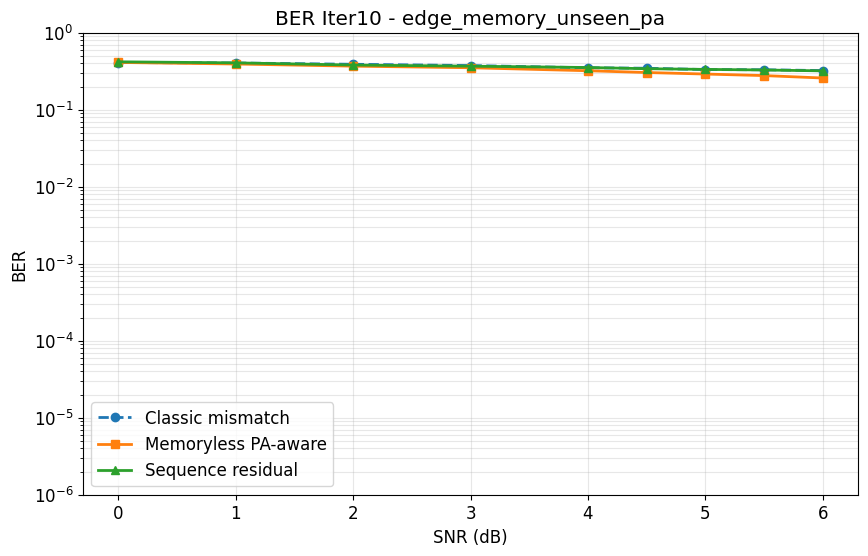

Saved: c:\Users\Monkez-PC\Desktop\Luận Văn\BIBCM-ID-20260430T042613Z-3-001\python_code\sequence_memory_residual_results


In [9]:
def json_safe(obj):
    if isinstance(obj, dict):
        return {str(k): json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [json_safe(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    return obj

out_dir = os.path.join(repo_root, "python_code", "sequence_memory_residual_results")
os.makedirs(out_dir, exist_ok=True)

csv_path = os.path.join(out_dir, "ber_summary.csv")
with open(csv_path, "w", encoding="utf-8") as f:
    headers = ["scenario", "mode", "snr_db", "blocks", "bits", "ber_iter1", "ber_iter5", "ber_iter10", "elapsed_s"]
    f.write(",".join(headers) + "\n")
    for row in REPORT_ROWS:
        f.write(",".join(str(row[h]) for h in headers) + "\n")

flat_curves = {}
for sc, per_mode in BER_RESULTS.items():
    for mode, curve in per_mode.items():
        flat_curves[f"{sc}__{mode}"] = curve
np.savez(os.path.join(out_dir, "ber_curves.npz"), dB_range=np.array(dB_range), **flat_curves)

with open(os.path.join(out_dir, "config.json"), "w", encoding="utf-8") as f:
    json.dump(json_safe({
        "TRAIN_PA_RANGE": TRAIN_PA_RANGE,
        "TRAIN_MEMORY_RANGE": TRAIN_MEMORY_RANGE,
        "TEST_SCENARIOS": TEST_SCENARIOS,
        "WINDOW_RADIUS": WINDOW_RADIUS,
        "QUICK_TRAIN": QUICK_TRAIN,
        "TRAIN_STEPS": TRAIN_STEPS,
        "QUICK_RUN": QUICK_RUN,
        "BLOCKS_BY_SNR": BLOCKS_BY_SNR,
        "symbol_metrics": symbol_metrics,
    }), f, indent=2)

styles = {
    "mismatch": ("--o", "Classic mismatch"),
    "memoryless_pa": ("-s", "Memoryless PA-aware"),
    "sequence": ("-^", "Sequence residual"),
}

for sc in TEST_SCENARIOS:
    plt.figure(figsize=(10, 6))
    for mode, (style, label) in styles.items():
        plt.semilogy(dB_range, np.maximum(BER_RESULTS[sc][mode][9], 1e-7), style, lw=2, label=label)
    plt.grid(True, which="both", alpha=0.3)
    plt.xlabel("SNR (dB)")
    plt.ylabel("BER")
    plt.title(f"BER Iter10 - {sc}")
    plt.ylim(1e-6, 1)
    plt.legend()
    plt.show()

print("Saved:", out_dir)

## 8. Bảng kết quả và cách diễn giải

Nếu `sequence` tốt hơn `mismatch` và `memoryless_pa` khi có PA memory, điều đó cho thấy việc nhìn nhiều symbol giúp receiver học được méo phụ thuộc lân cận mà demapper từng symbol bỏ qua.

Nếu `sequence` chưa tốt, thử tăng cửa sổ, thêm residual gate, hoặc train nhiều hơn trên vùng SNR mục tiêu.

In [10]:
try:
    import pandas as pd
    df = pd.DataFrame(REPORT_ROWS)
    display(df[["scenario", "mode", "snr_db", "blocks", "ber_iter1", "ber_iter5", "ber_iter10"]])
    display(df.pivot_table(index=["scenario", "snr_db"], columns="mode", values="ber_iter10"))
except Exception:
    for row in REPORT_ROWS:
        print(
            f"{row['scenario']:18s} | {row['mode']:9s} | SNR={row['snr_db']:>4} | "
            f"Iter1={row['ber_iter1']:.3e} Iter5={row['ber_iter5']:.3e} Iter10={row['ber_iter10']:.3e}"
        )

memoryless_mild_pa | mismatch  | SNR=   0 | Iter1=3.462e-01 Iter5=3.381e-01 Iter10=3.381e-01
memoryless_mild_pa | mismatch  | SNR=   1 | Iter1=3.143e-01 Iter5=3.017e-01 Iter10=3.014e-01
memoryless_mild_pa | mismatch  | SNR=   2 | Iter1=2.798e-01 Iter5=2.529e-01 Iter10=2.529e-01
memoryless_mild_pa | mismatch  | SNR=   3 | Iter1=2.472e-01 Iter5=2.012e-01 Iter10=2.001e-01
memoryless_mild_pa | mismatch  | SNR=   4 | Iter1=2.065e-01 Iter5=1.272e-01 Iter10=1.059e-01
memoryless_mild_pa | mismatch  | SNR= 4.5 | Iter1=1.763e-01 Iter5=6.069e-02 Iter10=8.757e-03
memoryless_mild_pa | mismatch  | SNR=   5 | Iter1=1.627e-01 Iter5=2.267e-02 Iter10=0.000e+00
memoryless_mild_pa | mismatch  | SNR= 5.5 | Iter1=1.334e-01 Iter5=2.188e-03 Iter10=0.000e+00
memoryless_mild_pa | mismatch  | SNR=   6 | Iter1=1.127e-01 Iter5=3.255e-05 Iter10=0.000e+00
memoryless_mild_pa | memoryless_pa | SNR=   0 | Iter1=3.398e-01 Iter5=3.321e-01 Iter10=3.321e-01
memoryless_mild_pa | memoryless_pa | SNR=   1 | Iter1=3.057e-01 It